In [1]:
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots  # noqa
import seaborn as sns

FONTSIZE = 8

PHI = (1 + math.sqrt(5)) / 2

FIG_WIDTH_IN = 12.2 / 2.54
FIGSIZE = (FIG_WIDTH_IN, FIG_WIDTH_IN / PHI)

mpl.rcdefaults()

plt.style.use(["science", "grid", "scatter", "ieee"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": FONTSIZE,
        "font.serif": [],
        "font.sans-serif": [],
        "font.cursive": [],
        "font.fantasy": [],
        "font.monospace": [],
        "text.usetex": True,
        "text.latex.preamble": "",
        # TODO: Is this necessary?
        "mathtext.fontset": "cm",
        "axes.titlesize": FONTSIZE,
        "axes.labelsize": FONTSIZE,
        "xtick.labelsize": FONTSIZE,
        "ytick.labelsize": FONTSIZE,
        "legend.fontsize": FONTSIZE,
        "legend.title_fontsize": FONTSIZE,
        "figure.titlesize": FONTSIZE,
        "figure.labelsize": FONTSIZE,
        "figure.figsize": FIGSIZE,
        "figure.dpi": 1200,
        "figure.constrained_layout.use": True,
        "savefig.format": "pgf",
        "savefig.bbox": None,
        # TODO: Is this necessary?
        "savefig.pad_inches": 0,
        "savefig.transparent": True,
        "pgf.rcfonts": False,
        "pgf.preamble": "",
        "pgf.texsystem": "pdflatex",
        # "figure.constrained_layout.h_pad": 0,
        # "figure.constrained_layout.hspace": 0,
        # "figure.constrained_layout.w_pad": 0,
        # "figure.constrained_layout.wspace": 0,
        # "font.stretch": 9.5,
        # "hatch.linewidth": 0.5,
        # "legend.borderaxespad": 0,
        # "legend.borderpad": 0,
        # "legend.fancybox": False,
        # "legend.handletextpad": 0,
        # "savefig.pad_inches": 0,
        # "xtick.major.pad": 4,
        # "xtick.minor.pad": 4,
        # "ytick.major.pad": 4,
        # "ytick.minor.pad": 4,
    }
)

sns.set_palette("colorblind")

In [2]:
def load_and_clean_survey(path):
    """Loads survey data and applies mappings/categorization."""
    df = pd.read_csv(path)

    # Rename
    rename_map = {
        "gender": "Sex",
        "age": "Age",
        "education": "Education Level",
        "employment": "Employment Status",
        "income": "Monthly Income",
        "car_own": "Car Ownership",
    }
    df = df.rename(columns=rename_map)

    # Categorical Mappings
    mappings = {
        "Sex": {"0: feamale": "Female", "1: male": "Male"},
        "Education Level": {
            "2: high school": "Second.",
            "3: bachelor": "Graduate",
            "4: master or phd": "Postgrad.",
        },
        "Employment Status": {
            "1: inactive": "Inactive",
            "2: unemployed": "Unemp.",
            "3: student": "Student",
            "4: active": "Active",
        },
        "Monthly Income": {
            "0: no income": "0",
            "1: 750 or less": r"$\le 0.75$",
            "2: 750-1500": r"$< 1.5$",
            "3: 1500-2500": r"$< 2.5$",
            "4: 2500 or more": r"$\ge 2.5$",
        },
        "Car Ownership": {"0: no": "No", "1: yes": "Yes"},
    }

    orders = {
        "Sex": ["Male", "Female"],
        "Education Level": ["Second.", "Graduate", "Postgrad."],
        "Employment Status": ["Student", "Unemp.", "Inactive", "Active"],
        "Monthly Income": ["0", r"$\le 0.75$", r"$< 1.5$", r"$< 2.5$", r"$\ge 2.5$"],
        "Car Ownership": ["Yes", "No"],
    }

    for col, mapping in mappings.items():
        df[col] = df[col].map(mapping)
        df[col] = pd.Categorical(df[col], categories=orders[col], ordered=True)

    # Binning Age
    bins = [0, 9, 19, 29, 39, 49, 59, 69, 79, np.inf]
    labels = [
        "0-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
    ]
    df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

    return df


survey = load_and_clean_survey("res/survey/survey.csv")
survey

,pid,Sex,Age,Education Level,Employment Status,Monthly Income,Car Ownership,home,dest1,purp1,...,max_time1,min_time2,max_time2,min_time3,max_time3,min_time4,max_time4,min_time5,max_time5,Age Group
0,101,Male,28.0,Postgrad.,Active,$< 1.5$,No,2.0,15,1: work,...,11.0,17.0,20.0,20.0,23.0,23.0,29.0,NaN,NaN,20-29
1,102,Female,28.0,Second.,Student,0,Yes,12.0,12,3: education,...,14.0,17.0,20.0,20.0,23.0,NaN,NaN,NaN,NaN,20-29
2,103,Female,27.0,Graduate,Active,$< 1.5$,Yes,15.0,15,1: work,...,14.0,14.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,20-29
3,104,Female,18.0,Postgrad.,Active,$< 1.5$,No,7.0,30,1: work,...,14.0,14.0,17.0,20.0,23.0,NaN,NaN,NaN,NaN,10-19
4,105,Male,18.0,Postgrad.,Active,$< 2.5$,Yes,22.0,35,5: recreation,...,20.0,20.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,10-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,603,Male,22.0,Postgrad.,Student,$\le 0.75$,Yes,8.0,8,7: other,...,20.0,32.0,35.0,44.0,47.0,NaN,NaN,NaN,NaN,20-29
457,606,Female,53.0,Graduate,Inactive,$< 1.5$,Yes,18.0,18,7: other,...,14.0,11.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,50-59
458,607,Male,75.0,Second.,Inactive,$< 1.5$,Yes,35.0,18,4: market,...,14.0,32.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,70-79
459,608,Male,49.0,Postgrad.,Active,$< 2.5$,No,1.0,22,1: work,...,11.0,17.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,40-49


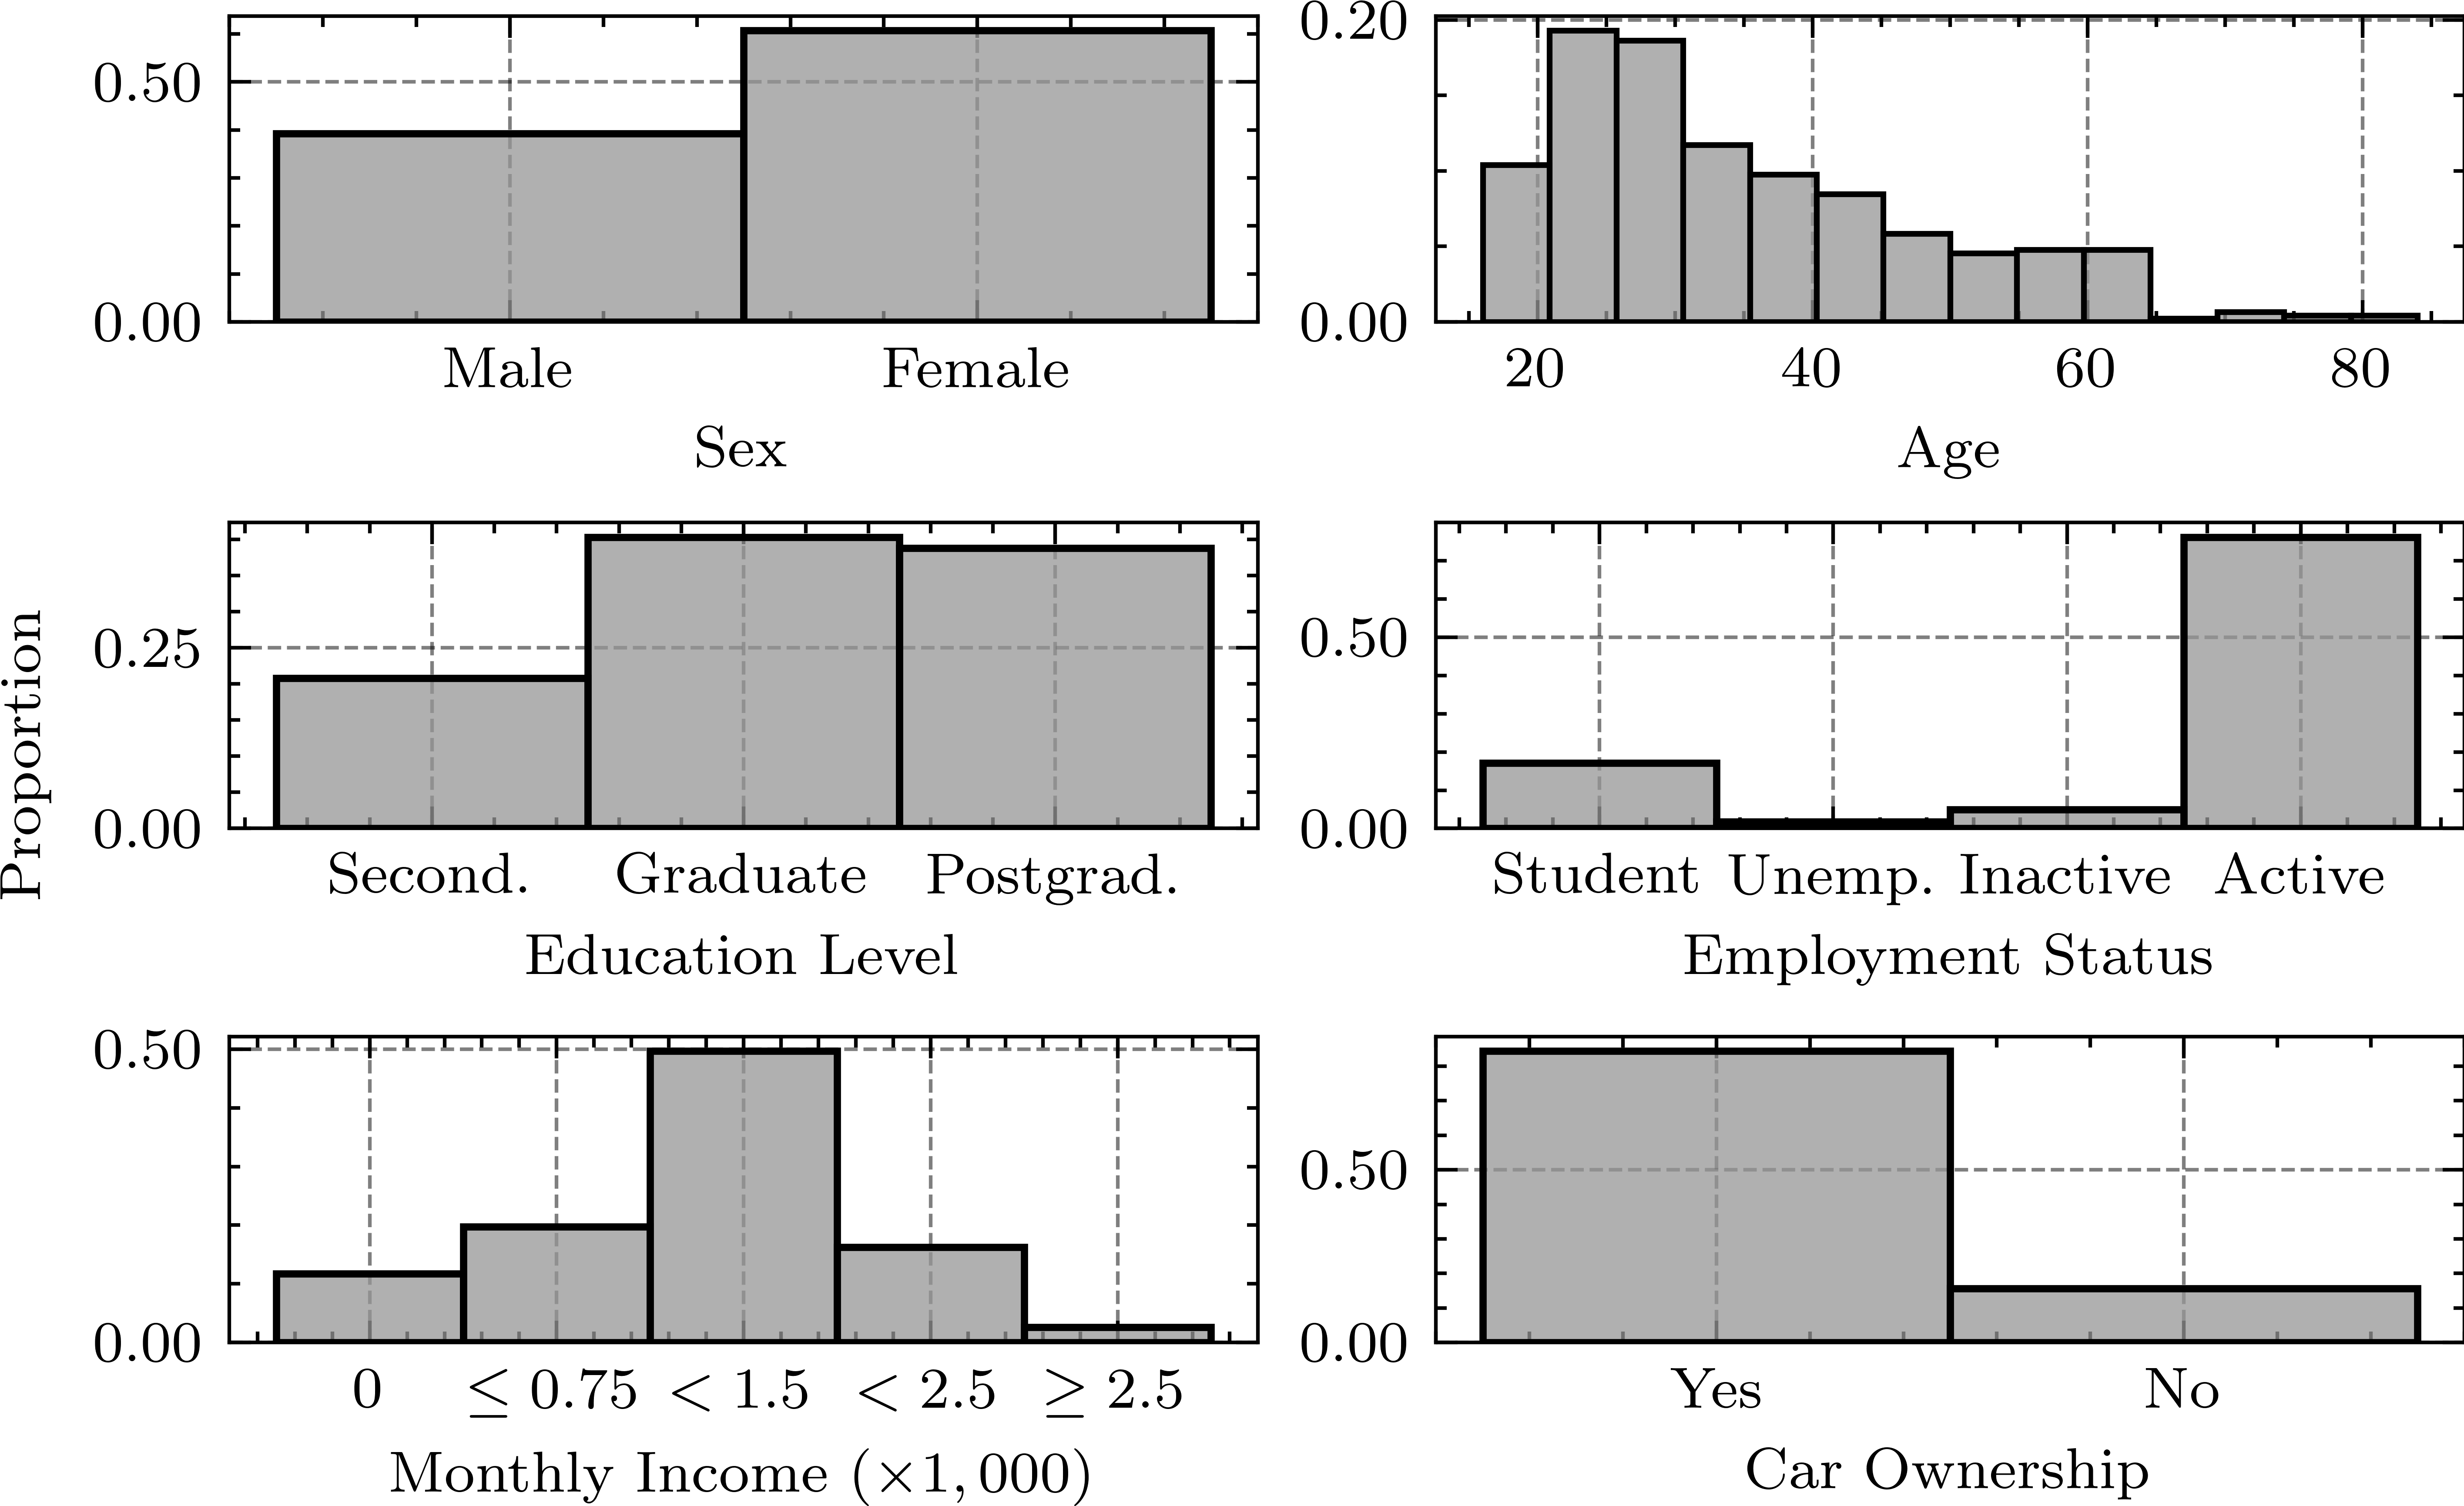

In [3]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=FIGSIZE, squeeze=True)
for ax, column in zip(
    axs.ravel(),
    [
        "Sex",
        "Age",
        "Education Level",
        "Employment Status",
        "Monthly Income",
        "Car Ownership",
    ],
):
    data = survey[column]
    sns.histplot(
        data, stat="proportion", discrete=column != "Age", color="#969696", ax=ax
    )

    if column == "Monthly Income":
        ax.set_xlabel(r"Monthly Income ($\times 1,000$)")

    ax.set_ylabel("")
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

fig.supylabel("Proportion")

plt.savefig("figures/MarginalDistributions")

In [4]:
from scipy.stats import chi2_contingency


# 1. THE CORRECTED FUNCTION
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)

    # correction=False is crucial for the diagonal to be 1.0
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table, correction=False)

    n = contingency_table.sum().sum()
    if n <= 1:
        return 0.0

    phi2 = chi2_statistic / n
    r, k = contingency_table.shape

    # Bias correction (Bergsma, 2013)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))

    # Corrected dimensions
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    r_corr = r - ((r - 1) ** 2) / (n - 1)

    denominator = min(k_corr - 1, r_corr - 1)

    if denominator <= 0:
        return 0.0

    return np.sqrt(phi2corr / denominator)


# ---------------------------------------------------------
# 3. BIN THE AGE COLUMN
# Logic: 0-14, 15-29, 30-44, 45-59, 60-74, 75+
bins = [0, 9, 19, 29, 39, 49, 59, 69, 79, np.inf]
labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89"]

# create a new column 'Age Group'
survey["Age Group"] = pd.cut(
    survey["Age"], bins=bins, labels=labels, include_lowest=True
)

# ---------------------------------------------------------
# 4. CALCULATE MATRIX
categorical_vars = [
    "Sex",
    "Age Group",  # Use the new binned column, not the raw 'Age'
    "Education Level",
    "Employment Status",
    "Monthly Income",
    "Car Ownership",
]

cramers_v_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for var1 in categorical_vars:
    for var2 in categorical_vars:
        cramers_v_matrix.loc[var1, var2] = cramers_v(survey[var1], survey[var2])

# Convert to float for clean display
cramers_v_matrix = cramers_v_matrix.astype(float)

cramers_v_matrix

,Sex,Age Group,Education Level,Employment Status,Monthly Income,Car Ownership
Sex,1.000000,0.000000,0.052673,0.060621,0.130401,0.000000
Age Group,0.000000,1.000000,0.220442,0.452141,0.228117,0.000000
Education Level,0.052673,0.220442,1.000000,0.410252,0.392168,0.000000
Employment Status,0.060621,0.452141,0.410252,1.000000,0.457309,0.117933
Monthly Income,0.130401,0.228117,0.392168,0.457309,1.000000,0.079440
Car Ownership,0.000000,0.000000,0.000000,0.117933,0.079440,1.000000


In [ ]:
sns.heatmap(cramers_v_matrix, annot=True, fmt=".2f", cmap="Blues")

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=FIGSIZE, squeeze=True)

sns.histplot(
    survey,
    x="Monthly Income",
    hue="Employment Status",
    stat="proportion",
    multiple="stack",
    # palette=sns.color_palette("Set1", n_colors=4),
    ax=axs[0, 0],
)
axs[0, 0].text(
    0.95,
    # TODO: Tune this value to be the same as the x-pad.
    0.90,
    rf"$V = {cramers_v_matrix.at['Monthly Income', 'Employment Status']:.3f}$",
    transform=axs[0, 0].transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    # TODO: Align this configuration with the legend params.
    bbox=dict(
        alpha=mpl.rcParams["legend.framealpha"],
        edgecolor=mpl.rcParams["legend.edgecolor"],
        facecolor="#FFFFFF",
    ),
)
sns.histplot(
    survey,
    x="Age",
    hue="Employment Status",
    stat="proportion",
    multiple="stack",
    # palette=sns.color_palette("Set1", n_colors=4),
    legend=False,
    ax=axs[0, 1],
)
axs[0, 1].text(
    0.95,
    # TODO: Tune this value to be the same as the x-pad.
    0.90,
    rf"$V = {cramers_v_matrix.at['Age Group', 'Employment Status']:.3f}$",
    transform=axs[0, 1].transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    # TODO: Align this configuration with the legend params.
    bbox=dict(
        alpha=mpl.rcParams["legend.framealpha"],
        edgecolor=mpl.rcParams["legend.edgecolor"],
        facecolor="#FFFFFF",
    ),
)
sns.histplot(
    survey,
    x="Employment Status",
    hue="Education Level",
    stat="proportion",
    multiple="stack",
    palette=sns.color_palette("Purples", n_colors=3),
    legend=False,
    ax=axs[1, 0],
)
axs[1, 0].text(
    0.05,
    # TODO: Tune this value to be the same as the x-pad.
    0.90,
    rf"$V = {cramers_v_matrix.at['Employment Status', 'Education Level']:.3f}$",
    transform=axs[1, 0].transAxes,
    verticalalignment="top",
    horizontalalignment="left",
    # TODO: Align this configuration with the legend params.
    bbox=dict(
        alpha=mpl.rcParams["legend.framealpha"],
        edgecolor=mpl.rcParams["legend.edgecolor"],
        facecolor="#FFFFFF",
    ),
)
sns.histplot(
    survey,
    x="Monthly Income",
    hue="Education Level",
    stat="proportion",
    multiple="stack",
    palette=sns.color_palette("Purples", n_colors=3),
    ax=axs[1, 1],
)
axs[1, 1].text(
    0.95,
    # TODO: Tune this value to be the same as the x-pad.
    0.90,
    rf"$V = {cramers_v_matrix.at['Education Level', 'Monthly Income']:.3f}$",
    transform=axs[1, 1].transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    # TODO: Align this configuration with the legend params.
    bbox=dict(
        alpha=mpl.rcParams["legend.framealpha"],
        edgecolor=mpl.rcParams["legend.edgecolor"],
        facecolor="#FFFFFF",
    ),
)

for ax in axs.ravel():
    ax.set_ylabel("")
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

fig.supylabel("Proportion")

# Employment Status
leg1_obj = axs[0, 0].legend_
h1 = leg1_obj.legend_handles
l1 = [t.get_text() for t in leg1_obj.get_texts()]

# Monthly Income
leg2_obj = axs[1, 1].legend_
h2 = leg2_obj.legend_handles
l2 = [t.get_text() for t in leg2_obj.get_texts()]

for ax in axs.ravel():
    if ax.get_legend():
        ax.get_legend().remove()

fig.canvas.draw()
pos_left = axs[0, 0].get_position()
pos_right = axs[0, 1].get_position()

center_left = (pos_left.x0 + pos_left.x1) / 2
center_right = (pos_right.x0 + pos_right.x1) / 2
leg1 = fig.legend(
    h1,
    l1,
    title="Employment Status",
    loc="upper center",
    bbox_to_anchor=(center_left, 0),
    ncol=2,
)
leg2 = fig.legend(
    h2,
    l2,
    title="Education Level",
    loc="upper center",
    bbox_to_anchor=(center_right, 0),
    ncol=2,
)

plt.savefig(
    "figures/BivariateDistributions",
    # Resize the figure to fit the legends.
    bbox_inches="tight",
)